In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.covariance import graphical_lasso, GraphicalLasso, GraphicalLassoCV
from tqdm.notebook import tqdm

In [2]:
df = pd.read_csv('../../data/hj_andrews_clean.csv')
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df = df.set_index('DATE_TIME')
df.head()

,PA002,PA003,PA004,PA005,PA006,PA009,PA010,PA011,PA012,PA013,...,PB331,PB332,PB333,PB335,PB337,PB343,PB346,PB356,PB357,PB358
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2011-05-01 01:00:00,0.2,0.6,0.9,0.2,0.9,0.5,0.7,0.5,0.6,-0.3,...,-1.1,-1.3,-1.3,-0.3,0.7,0.8,0.4,0.7,0.2,-2.7
2011-05-01 02:00:00,-0.1,0.4,0.6,-0.1,0.7,0.2,0.4,0.3,0.3,-0.5,...,-1.3,-1.4,-1.5,-0.7,0.7,0.4,0.1,0.4,-0.1,-3.0
2011-05-01 03:00:00,-0.3,0.3,0.5,-0.2,0.5,0.1,0.3,0.3,0.3,-0.6,...,-1.4,-1.6,-1.6,-1.0,0.4,0.4,0.0,0.3,-0.1,-3.3
2011-05-01 04:00:00,-0.4,0.1,0.2,-0.3,0.3,-0.1,0.2,0.2,0.1,-0.8,...,-1.7,-1.8,-1.7,-1.2,-0.2,0.1,-0.2,0.2,-0.3,-3.5
2011-05-01 05:00:00,-0.5,0.1,0.1,-0.6,0.4,-0.1,-0.1,0.1,-0.1,-0.8,...,-1.9,-2.1,-2.1,-1.3,-0.4,0.0,-0.1,0.0,-0.5,-3.8


In [3]:
#df -= df.mean()
#df /= df.std()
df.head()

,PA002,PA003,PA004,PA005,PA006,PA009,PA010,PA011,PA012,PA013,...,PB331,PB332,PB333,PB335,PB337,PB343,PB346,PB356,PB357,PB358
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2011-05-01 01:00:00,0.2,0.6,0.9,0.2,0.9,0.5,0.7,0.5,0.6,-0.3,...,-1.1,-1.3,-1.3,-0.3,0.7,0.8,0.4,0.7,0.2,-2.7
2011-05-01 02:00:00,-0.1,0.4,0.6,-0.1,0.7,0.2,0.4,0.3,0.3,-0.5,...,-1.3,-1.4,-1.5,-0.7,0.7,0.4,0.1,0.4,-0.1,-3.0
2011-05-01 03:00:00,-0.3,0.3,0.5,-0.2,0.5,0.1,0.3,0.3,0.3,-0.6,...,-1.4,-1.6,-1.6,-1.0,0.4,0.4,0.0,0.3,-0.1,-3.3
2011-05-01 04:00:00,-0.4,0.1,0.2,-0.3,0.3,-0.1,0.2,0.2,0.1,-0.8,...,-1.7,-1.8,-1.7,-1.2,-0.2,0.1,-0.2,0.2,-0.3,-3.5
2011-05-01 05:00:00,-0.5,0.1,0.1,-0.6,0.4,-0.1,-0.1,0.1,-0.1,-0.8,...,-1.9,-2.1,-2.1,-1.3,-0.4,0.0,-0.1,0.0,-0.5,-3.8


In [4]:
latlong = pd.read_csv("../../data/HJA_xy_coord_elv_bird_pts.csv")
latlong.head()

,Plot,PlotNum,X,Y,Elv (m)
0,2,2,563755,4897830,603.23
1,3,3,563755,4897530,648.59
2,4,4,563755,4897230,766.32
3,5,5,563755,4896630,912.25
4,6,6,563755,4896330,993.51


In [5]:
latlong.tail()

,Plot,PlotNum,X,Y,Elv (m)
180,PC14,514,567112,4900997,964.51
181,PC15,515,566230,4901776,970.79
182,PC16,516,565617,4901912,1030.05
183,PC17,517,568874,4902589,1301.42
184,PC18,518,569010,4902722,1338.87


In [6]:
latlong_df = latlong[~latlong['Plot'].str.contains("PC")]
latlong_df.tail()

,Plot,PlotNum,X,Y,Elv (m)
162,354,354,561686,4895983,843.02
163,356,356,562384,4895868,885.60
164,357,357,562681,4895810,873.27
165,358,358,570678,4895092,1310.27
166,400,400,567657,4895416,1055.28


In [7]:
df_nums = [x[2:] for x in list(df.columns)]
df_nums

['002',
 '003',
 '004',
 '005',
 '006',
 '009',
 '010',
 '011',
 '012',
 '013',
 '016',
 '017',
 '018',
 '019',
 '020',
 '021',
 '023',
 '027',
 '028',
 '029',
 '031',
 '032',
 '036',
 '037',
 '038',
 '039',
 '040',
 '041',
 '042',
 '044',
 '045',
 '048',
 '051',
 '053',
 '054',
 '059',
 '062',
 '063',
 '064',
 '065',
 '066',
 '076',
 '077',
 '078',
 '079',
 '080',
 '081',
 '200',
 '203',
 '204',
 '207',
 '208',
 '209',
 '210',
 '211',
 '217',
 '224',
 '226',
 '233',
 '234',
 '235',
 '239',
 '240',
 '241',
 '243',
 '245',
 '246',
 '247',
 '248',
 '249',
 '250',
 '252',
 '253',
 '256',
 '257',
 '258',
 '259',
 '260',
 '265',
 '266',
 '270',
 '272',
 '273',
 '274',
 '275',
 '276',
 '277',
 '279',
 '303',
 '304',
 '305',
 '306',
 '307',
 '308',
 '309',
 '310',
 '311',
 '312',
 '314',
 '315',
 '317',
 '318',
 '322',
 '323',
 '324',
 '327',
 '328',
 '329',
 '330',
 '334',
 '336',
 '338',
 '339',
 '340',
 '341',
 '342',
 '344',
 '345',
 '347',
 '348',
 '349',
 '350',
 '351',
 '352',
 '353',


In [8]:
latlong_df["Plot"] = [str(x.zfill(3)) for x in latlong_df["Plot"].values]
latlong_df.head()

/tmp/ipykernel_3247/812741481.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latlong_df["Plot"] = [str(x.zfill(3)) for x in latlong_df["Plot"].values]


,Plot,PlotNum,X,Y,Elv (m)
0,002,2,563755,4897830,603.23
1,003,3,563755,4897530,648.59
2,004,4,563755,4897230,766.32
3,005,5,563755,4896630,912.25
4,006,6,563755,4896330,993.51


In [9]:
set(df_nums) - set(latlong_df["Plot"])

{'506'}

In [10]:
df_copy = df.copy()
df_copy.columns = df_nums
df_copy = df_copy.loc[:, df_copy.columns != '506']
df_copy.shape

(28487, 167)

In [11]:
set(df_copy.columns) - set(latlong_df["Plot"])

set()

In [12]:
df_copy_sorted = df_copy.sort_index(axis=1)
df_copy_sorted.head()

,002,003,004,005,006,008,009,010,011,012,...,349,350,351,352,353,354,356,357,358,400
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2011-05-01 01:00:00,0.2,0.6,0.9,0.2,0.9,-0.4,0.5,0.7,0.5,0.6,...,-0.3,0.3,0.7,-0.1,0.7,1.0,0.7,0.2,-2.7,0.0
2011-05-01 02:00:00,-0.1,0.4,0.6,-0.1,0.7,-0.7,0.2,0.4,0.3,0.3,...,-0.6,0.3,0.3,-0.6,0.5,0.7,0.4,-0.1,-3.0,-0.3
2011-05-01 03:00:00,-0.3,0.3,0.5,-0.2,0.5,-0.9,0.1,0.3,0.3,0.3,...,-0.8,0.0,0.3,-1.1,0.2,0.4,0.3,-0.1,-3.3,-0.3
2011-05-01 04:00:00,-0.4,0.1,0.2,-0.3,0.3,-1.1,-0.1,0.2,0.2,0.1,...,-1.0,-0.6,0.1,-1.3,-0.1,0.1,0.2,-0.3,-3.5,-0.6
2011-05-01 05:00:00,-0.5,0.1,0.1,-0.6,0.4,-1.3,-0.1,-0.1,0.1,-0.1,...,-1.1,-0.7,0.0,-1.5,-0.3,-0.1,0.0,-0.5,-3.8,-0.6


In [13]:
noon_df = df_copy_sorted[df_copy_sorted.index.hour == 12]
noon_df = noon_df.resample('d').mean()
noon_df.index.freq = 'd'
noon_df.head()

,002,003,004,005,006,008,009,010,011,012,...,349,350,351,352,353,354,356,357,358,400
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2011-05-01,11.1,10.5,9.8,5.8,5.9,13.4,10.9,6.1,7.2,8.0,...,13.2,9.3,8.2,14.5,7.4,7.8,8.1,5.7,15.9,8.4
2011-05-02,4.7,4.4,4.2,2.9,2.2,5.3,4.5,3.3,3.6,3.3,...,5.3,5.3,3.4,6.3,3.9,4.3,3.4,2.9,1.5,1.4
2011-05-03,8.9,8.2,7.8,5.7,5.1,10.1,8.5,6.0,7.2,7.3,...,10.0,7.6,7.4,11.8,7.7,8.2,7.4,5.6,8.7,5.3
2011-05-04,15.1,14.1,14.3,9.9,8.3,17.2,14.8,10.1,12.1,13.3,...,16.9,13.5,13.5,18.0,11.7,12.2,13.4,9.7,19.3,11.7
2011-05-05,11.8,11.4,11.5,7.9,6.3,12.7,11.8,8.2,10.1,9.8,...,12.5,11.5,9.9,11.9,9.8,10.3,9.9,7.8,9.7,7.5


In [14]:
noon_df.shape

(1187, 167)

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.structural import UnobservedComponents as UCM
from statsmodels.tsa.seasonal import STL

seasonal_df = pd.DataFrame()
trend_df = pd.DataFrame()
resid_df = pd.DataFrame()
for i in tqdm(range(noon_df.shape[1])):
    model = STL(noon_df.values[:, i], period=365)
    result = model.fit()
    seasonal_df[noon_df.columns[i]] = result.seasonal
    trend_df[noon_df.columns[i]] = result.trend
    resid_df[noon_df.columns[i]] = result.resid
seasonal_df.index = noon_df.index
trend_df.index = noon_df.index
resid_df.index = noon_df.index

  0%|          | 0/167 [00:00<?, ?it/s]

/tmp/ipykernel_3247/85624581.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  seasonal_df[noon_df.columns[i]] = result.seasonal
/tmp/ipykernel_3247/85624581.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  trend_df[noon_df.columns[i]] = result.trend
/tmp/ipykernel_3247/85624581.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragment

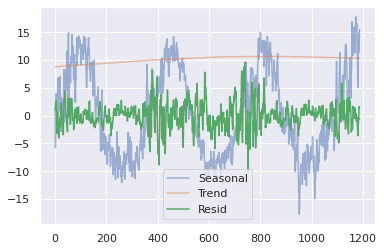

In [16]:
plt.plot(seasonal_df.values[:, 0], label='Seasonal', alpha=0.5)
plt.plot(trend_df.values[:, 0], label='Trend', alpha=0.5)
plt.plot(resid_df.values[:, 0], label='Resid')
plt.legend()

In [17]:
from sklearn import covariance, preprocessing

scaler = preprocessing.StandardScaler()
resid_scaled = scaler.fit_transform(resid_df.values)
resid_scaled

array([[ 0.46531334,  0.35331539,  0.51676253, ...,  0.20445209,
         1.27474844,  0.66279324],
       [ 0.73722209,  0.59903021,  0.83850967, ...,  0.68199305,
         0.62388375,  0.75249852],
       [ 0.98951624,  0.80642333,  0.94262062, ...,  0.79092768,
        -0.07228582,  0.80282119],
       ...,
       [ 0.69474781,  0.30721418,  0.62421908, ...,  0.48192437,
         0.34536937,  0.58932476],
       [ 0.57560598,  0.33372923,  0.47765567, ...,  0.47745069,
        -0.1717056 ,  0.38496794],
       [ 0.69648245,  0.30994984,  0.56573917, ...,  0.44824477,
         0.14174686,  0.42250632]])

In [18]:
resid_scaled.mean(axis=0), resid_scaled.std(axis=0)

(array([ 2.99301911e-18, -2.09511337e-17, -3.59162293e-17,  5.98603821e-18,
         2.69371720e-17,  1.79581146e-17, -2.09511337e-17,  1.49650955e-17,
         2.69371720e-17,  1.79581146e-17,  0.00000000e+00,  1.79581146e-17,
         0.00000000e+00,  1.79581146e-17, -8.97905732e-18, -8.97905732e-18,
        -1.49650955e-17,  1.19720764e-17,  1.79581146e-17,  2.69371720e-17,
        -2.99301911e-18,  2.99301911e-18,  2.39441528e-17, -2.39441528e-17,
        -2.39441528e-17, -2.39441528e-17, -5.98603821e-18, -1.79581146e-17,
         0.00000000e+00, -5.98603821e-18,  5.98603821e-18, -1.79581146e-17,
        -5.98603821e-18, -2.09511337e-17, -2.39441528e-17, -8.97905732e-18,
        -5.98603821e-18, -2.99301911e-18,  2.99301911e-18, -2.99301911e-18,
         0.00000000e+00, -1.79581146e-17,  0.00000000e+00, -2.99301911e-18,
         2.39441528e-17,  2.99301911e-18, -2.99301911e-18,  0.00000000e+00,
         8.97905732e-18, -2.09511337e-17, -1.19720764e-17,  1.19720764e-17,
         1.7

In [19]:
np.cov(resid_scaled, rowvar=0)

array([[1.00084317, 0.97711035, 0.96928898, ..., 0.97435502, 0.75401314,
        0.93059977],
       [0.97711035, 1.00084317, 0.96327982, ..., 0.96719978, 0.77695251,
        0.92913844],
       [0.96928898, 0.96327982, 1.00084317, ..., 0.98186192, 0.80641266,
        0.98178882],
       ...,
       [0.97435502, 0.96719978, 0.98186192, ..., 1.00084317, 0.79654207,
        0.97031506],
       [0.75401314, 0.77695251, 0.80641266, ..., 0.79654207, 1.00084317,
        0.82340571],
       [0.93059977, 0.92913844, 0.98178882, ..., 0.97031506, 0.82340571,
        1.00084317]])

In [20]:
np.savetxt('../../data/hj_andrews_resid.csv', resid_scaled)

<AxesSubplot:>

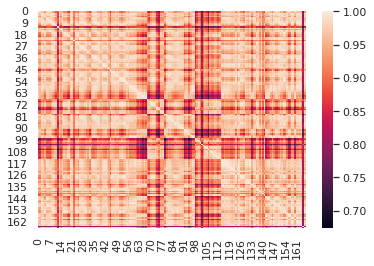

In [21]:
sns.heatmap(np.cov(resid_scaled, rowvar=0))

In [22]:
from scipy.spatial.distance import squareform

dist_matrix = np.cov(resid_scaled, rowvar=0)
print(dist_matrix.shape)
np.fill_diagonal(dist_matrix, 0.0)
dist_matrix = squareform(dist_matrix)
print(dist_matrix.shape)

(167, 167)
(13861,)


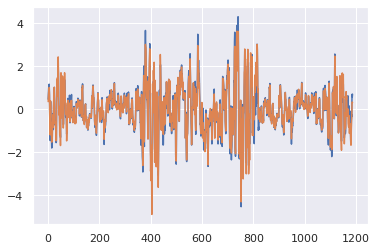

In [23]:
plt.plot(resid_scaled[:, 0])
plt.plot(resid_scaled[:, 1])

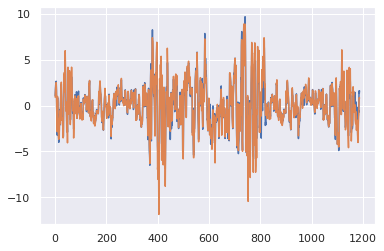

In [24]:
plt.plot(resid_df.values[:, 0])
plt.plot(resid_df.values[:, 1])

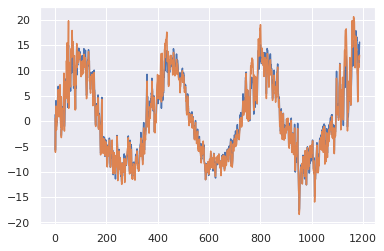

In [25]:
plt.plot(seasonal_df.values[:, 0])
plt.plot(seasonal_df.values[:, 1])

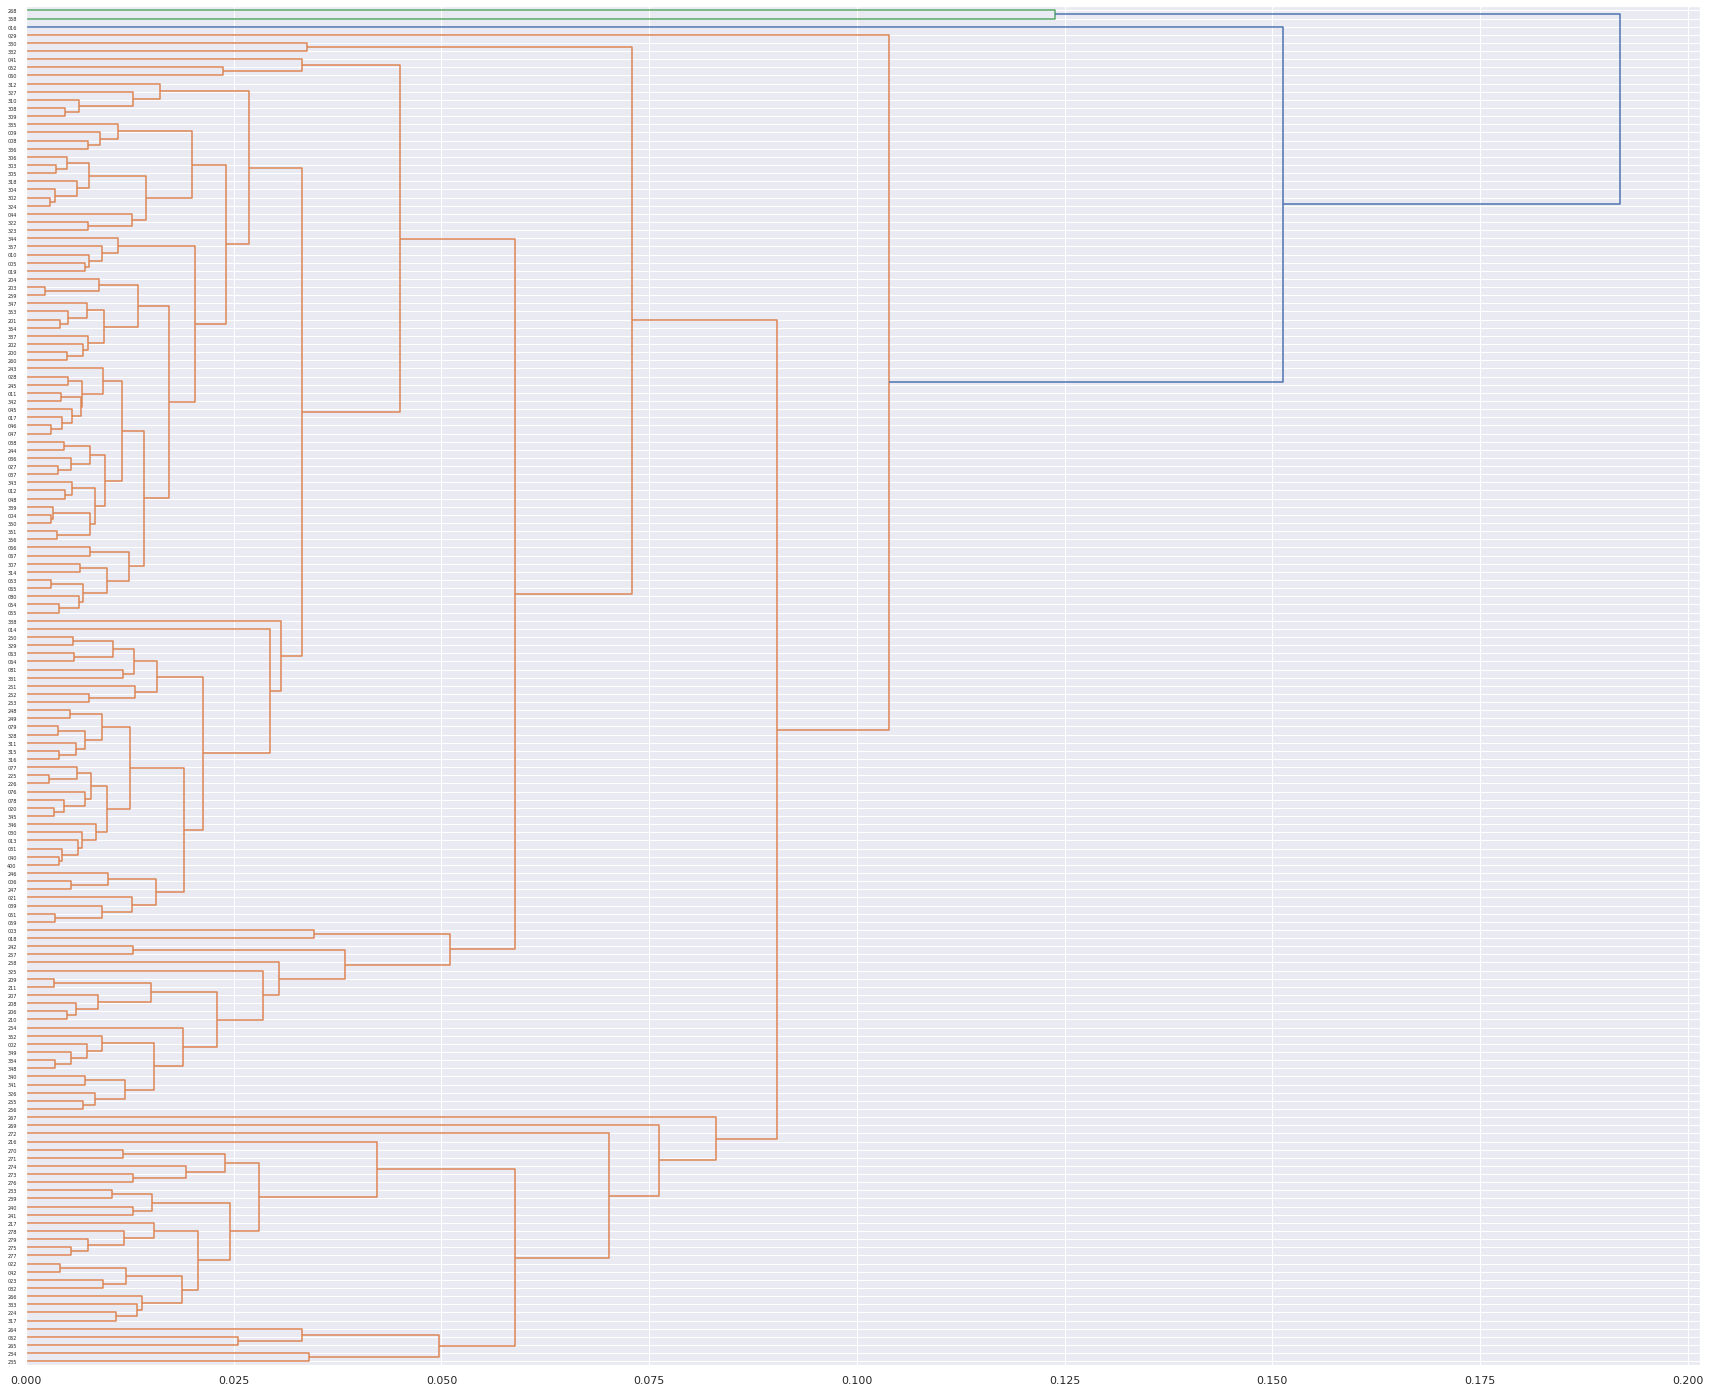

In [26]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.cluster import hierarchy
Z = linkage(resid_scaled.T,
            method='average',
            metric='correlation'# dissimilarity metric: max distance across all pairs of 
                                # records between two clusters
    )
# calculate full dendrogram and visualize it
plt.figure(figsize=(30, 25))
dendrogram(
            Z,
            orientation='right',
            labels=noon_df.columns,
            distance_sort='descending',
            show_leaf_counts=False
          )
plt.show()

In [27]:
Z.shape, resid_df.columns.shape

((166, 4), (167,))

In [28]:
cutree1 = hierarchy.cut_tree(Z, n_clusters=6).squeeze()
cutree1

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 2, 0, 0,
       3, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0])

/tmp/ipykernel_14185/3143367495.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Cluster')


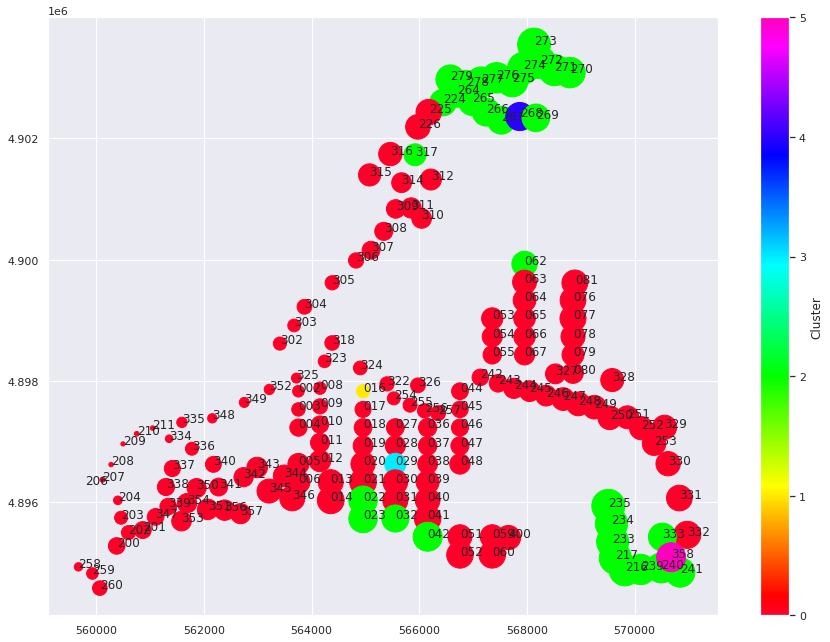

In [29]:
f, ax = plt.subplots(figsize=(15, 11))
plt.scatter(x=latlong_df['X'], 
            y=latlong_df['Y'], 
            c=cutree1, 
            cmap='gist_rainbow', 
            s=(latlong_df['Elv (m)']-latlong_df['Elv (m)'].min()))
plt.colorbar(label='Cluster')

for i, txt in enumerate(latlong_df['Plot']):
    plt.annotate(txt, (latlong_df['X'][i], latlong_df['Y'][i]))

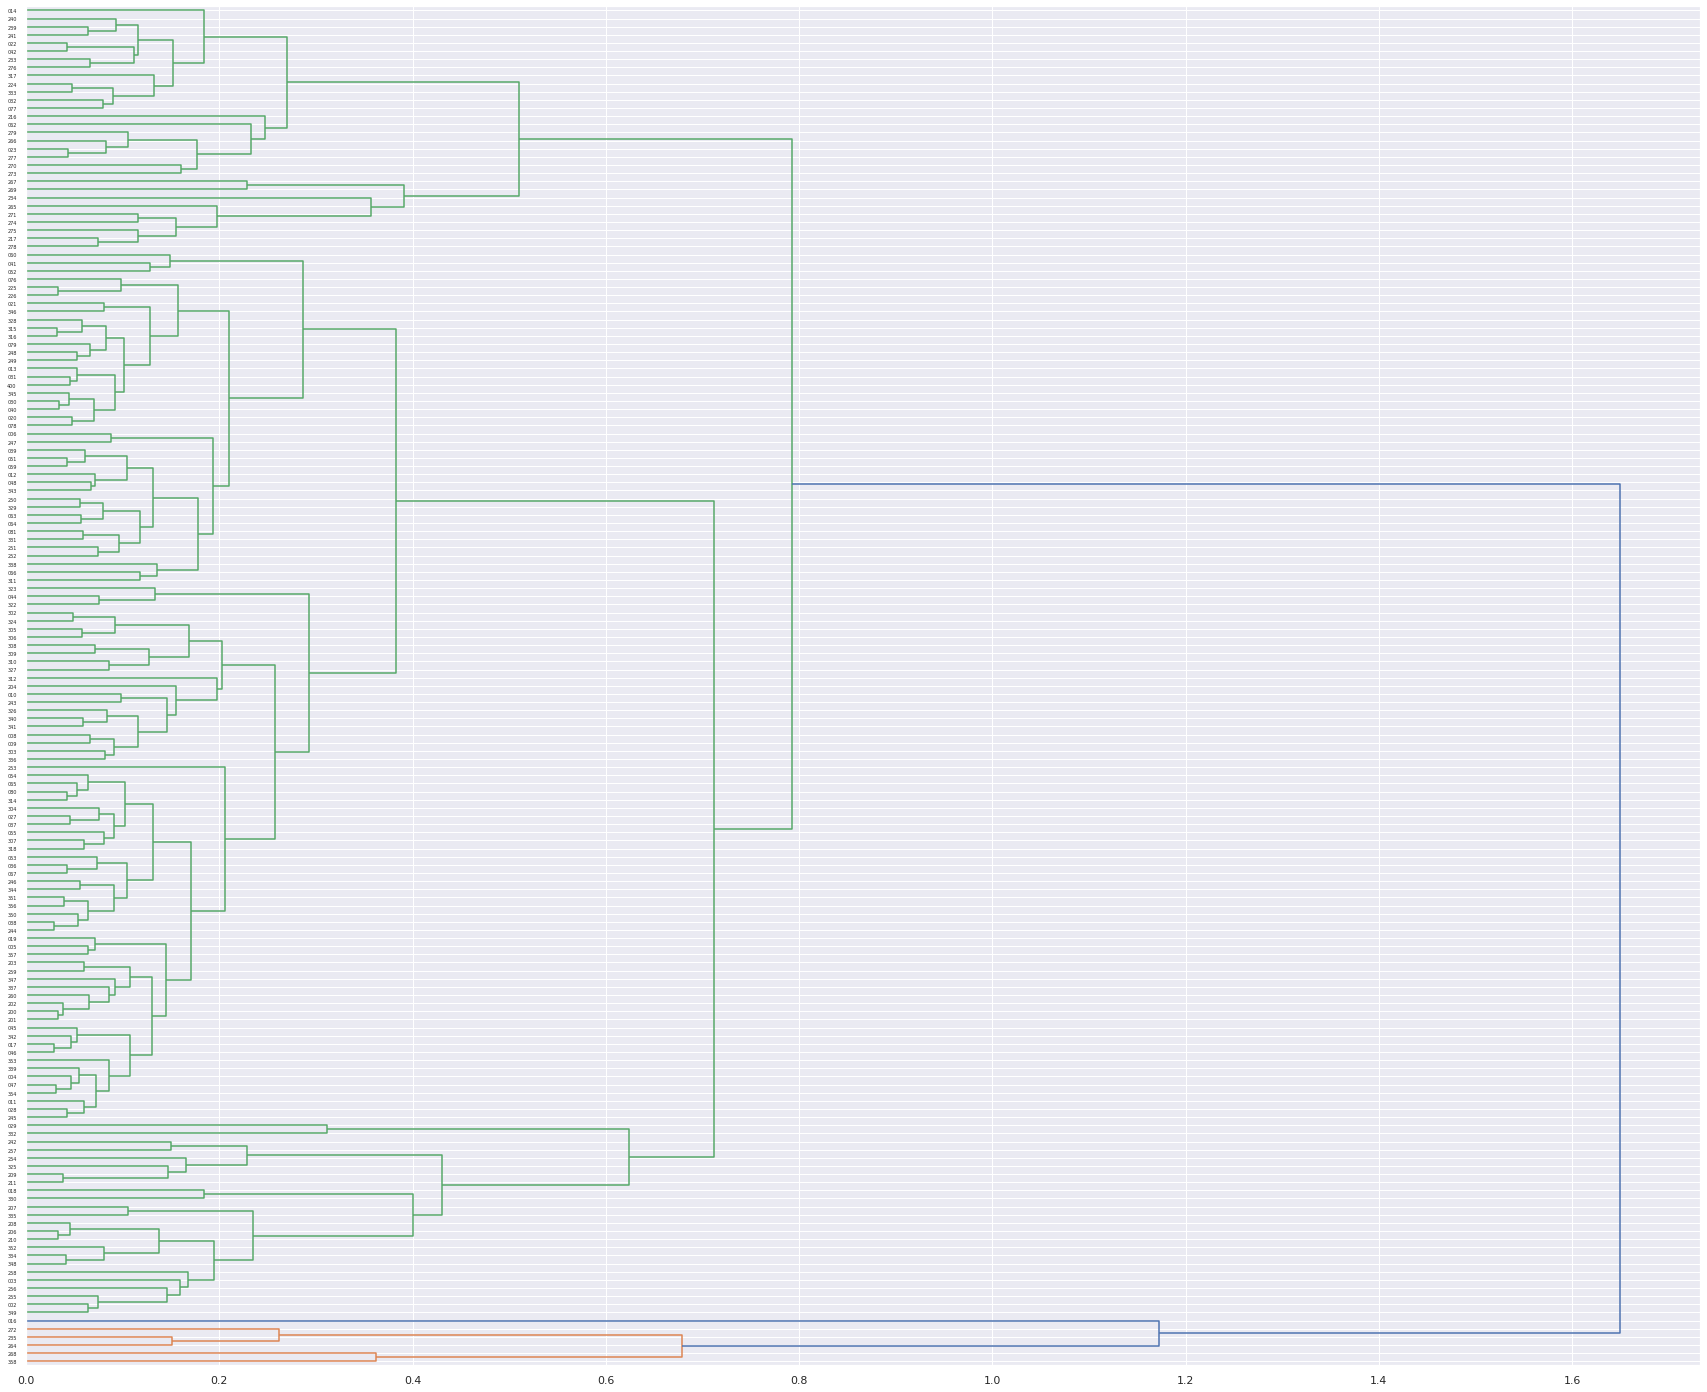

In [30]:
dmat = np.corrcoef(resid_scaled, rowvar=0)
dmat = hierarchy.distance.pdist(dmat)
Z = linkage(dmat,
            method='average'# dissimilarity metric: max distance across all pairs of 
                            # records between two clusters
    )
# calculate full dendrogram and visualize it
plt.figure(figsize=(30, 25))
dendrogram(
            Z,
            orientation='right',
            labels=noon_df.columns,
            distance_sort='descending',
            show_leaf_counts=False
          )
plt.show()

In [31]:
cutree1 = hierarchy.cut_tree(Z, n_clusters=25).squeeze()
cutree1

array([ 0,  0,  1,  1,  2,  3,  3,  3,  1,  2,  2,  4,  5,  1,  6,  1,  2,
        2,  4,  7,  1,  1,  8,  2,  2,  4,  1,  1,  1,  2,  2,  9,  4, 10,
        1,  1,  1,  2,  2,  9,  1,  1,  1,  2,  9, 11,  2,  2,  1,  2,  1,
        2,  4,  2,  2,  1,  2,  1,  1,  1,  1,  3,  0, 12,  0, 13,  0, 13,
       14, 15,  4,  2,  2,  4, 16, 17,  4,  4,  4, 18,  3,  1,  1,  1,  2,
        2,  2,  2,  2,  2,  1, 13,  0,  0, 18,  0,  1,  1, 17, 15,  7, 19,
       20, 21,  7, 15, 22,  7, 15, 15,  4,  7, 15,  7,  3,  3,  1,  3,  3,
        1,  3,  3,  3,  2,  3,  1,  2,  2,  4,  1, 10, 10,  3, 13,  3,  3,
        2,  2,  6,  2, 23,  4,  0, 12,  3,  1,  2,  1,  3,  3,  1,  2,  1,
        2,  2,  1,  0,  0,  1,  1,  0,  1,  1,  1,  1, 24,  2])

/tmp/ipykernel_14185/3143367495.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Cluster')


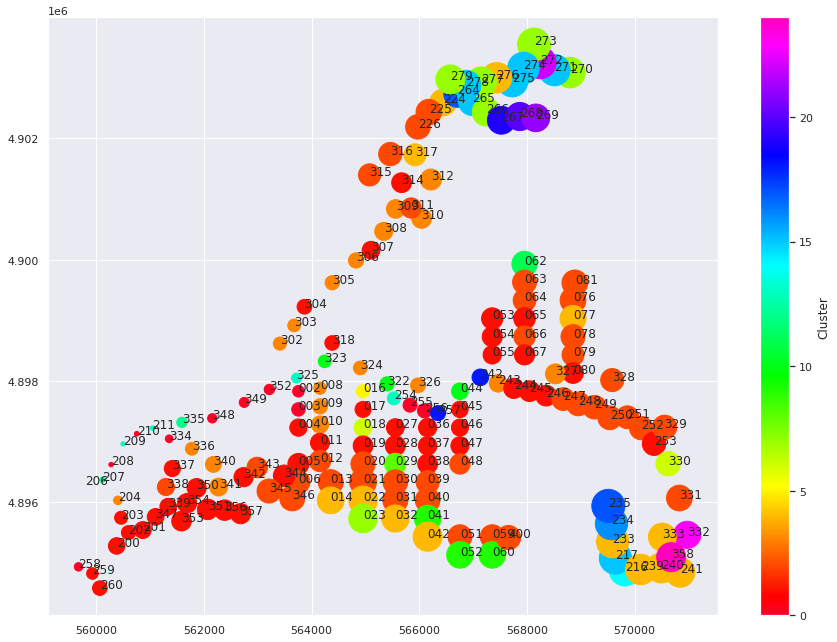

In [32]:
f, ax = plt.subplots(figsize=(15, 11))
plt.scatter(x=latlong_df['X'], 
            y=latlong_df['Y'], 
            c=cutree1, 
            cmap='gist_rainbow', 
            s=(latlong_df['Elv (m)']-latlong_df['Elv (m)'].min()))
plt.colorbar(label='Cluster')

for i, txt in enumerate(latlong_df['Plot']):
    plt.annotate(txt, (latlong_df['X'][i], latlong_df['Y'][i]))

In [33]:
import scipy
import scipy.cluster.hierarchy as sch

def cluster_corr(corr_array, inplace=False):
    """
    Rearranges the correlation matrix, corr_array, so that groups of highly 
    correlated variables are next to eachother 
    
    Parameters
    ----------
    corr_array : pandas.DataFrame or numpy.ndarray
        a NxN correlation matrix 
        
    Returns
    -------
    pandas.DataFrame or numpy.ndarray
        a NxN correlation matrix with the columns and rows rearranged
    """
    pairwise_distances = sch.distance.pdist(corr_array)
    linkage = sch.linkage(pairwise_distances, method='complete')
    cluster_distance_threshold = pairwise_distances.max()/2
    idx_to_cluster_array = sch.fcluster(linkage, cluster_distance_threshold, 
                                        criterion='distance')
    idx = np.argsort(idx_to_cluster_array)
    
    if not inplace:
        corr_array = corr_array.copy()
    
    if isinstance(corr_array, pd.DataFrame):
        return corr_array.iloc[idx, :].T.iloc[idx, :]
    return corr_array[idx, :][:, idx]

<AxesSubplot:>

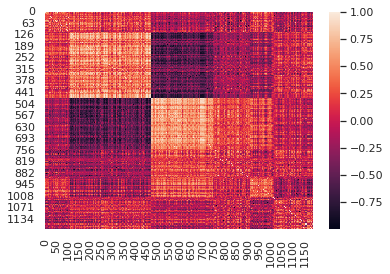

In [34]:
sns.heatmap(cluster_corr(np.corrcoef(resid_scaled)))

<AxesSubplot:>

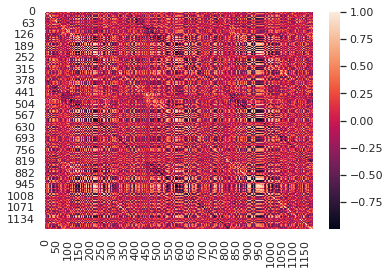

In [35]:
sns.heatmap(np.corrcoef(resid_scaled))

In [36]:
from sklearn import covariance, preprocessing

ret = GraphicalLasso(max_iter=1000, alpha=0.8, tol=1e-5).fit(resid_scaled)
ret

GraphicalLasso(alpha=0.8, max_iter=1000, tol=1e-05)

In [39]:
np.linalg.det(np.cov(resid_scaled.T))

0.0

In [87]:
precision = ret.precision_.copy()
precision[precision==-0.0] = 10.0
precision[precision==0.0] = 10.0
precision -= precision.min()
precision

array([[ 1.28479947,  0.05169573,  0.07244977, ...,  0.06546077,
        10.08093172, 10.08093172],
       [ 0.05169573,  1.25384531,  0.06961589, ...,  0.06458025,
        10.08093172, 10.08093172],
       [ 0.07244977,  0.06961589,  1.30725017, ...,  0.0722171 ,
        10.08093172,  0.07223053],
       ...,
       [ 0.06546077,  0.06458025,  0.0722171 , ...,  1.29382593,
        10.08093172,  0.07584893],
       [10.08093172, 10.08093172, 10.08093172, ..., 10.08093172,
         1.09627452, 10.08093172],
       [10.08093172, 10.08093172,  0.07223053, ...,  0.07584893,
        10.08093172,  1.30792313]])

<AxesSubplot:>

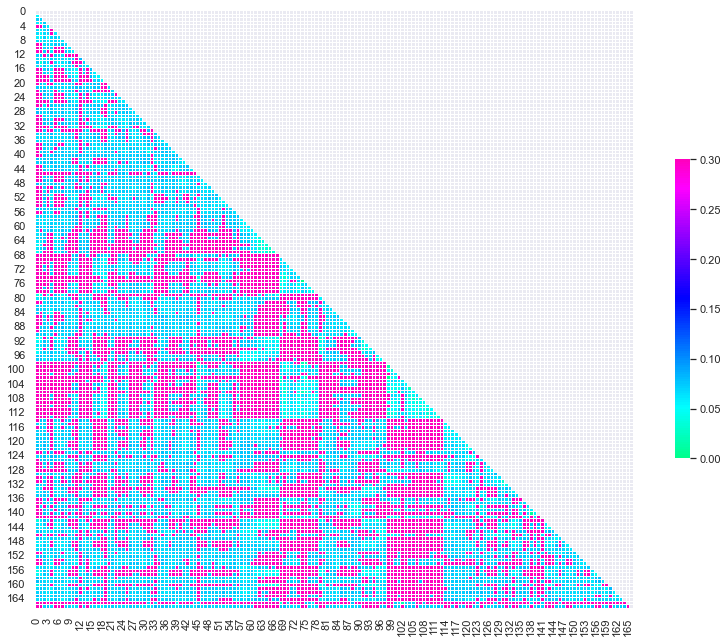

In [88]:
mask = np.triu(np.ones_like(precision, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(15, 11))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(precision, mask=mask, cmap='gist_rainbow', vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

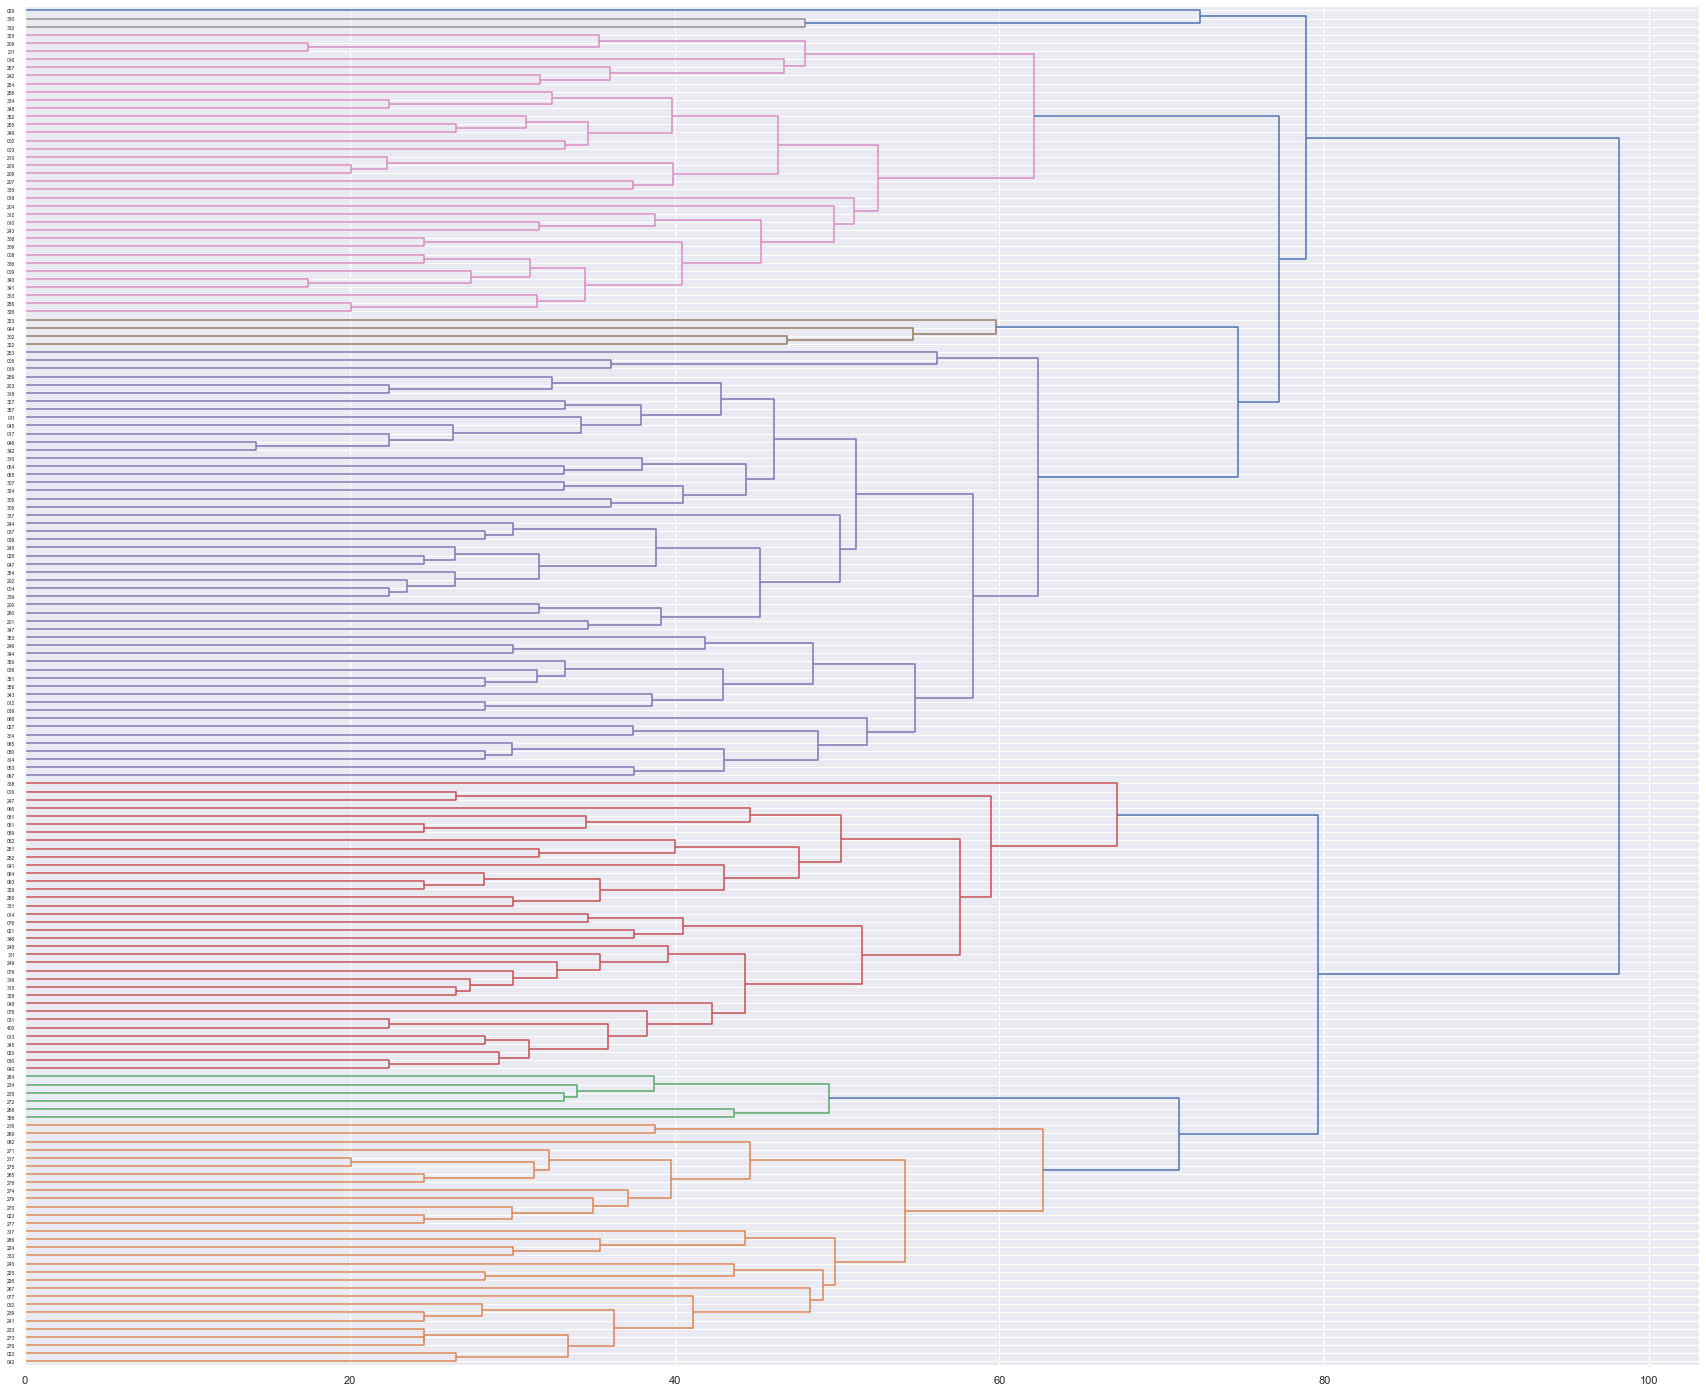

In [89]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import scipy.cluster.hierarchy as sch

pairwise_distances = sch.distance.pdist(precision)
Z = linkage(pairwise_distances,
            method='average'  # dissimilarity metric: max distance across all pairs of 
                               # records between two clusters
    )
# calculate full dendrogram and visualize it
plt.figure(figsize=(30, 25))
dendrogram(
            Z,
            orientation='right',
            labels=noon_df.columns,
            distance_sort='descending',
            show_leaf_counts=False
          )
plt.show()

In [90]:
cutree1 = hierarchy.cut_tree(Z, n_clusters=6).squeeze()
cutree1

array([0, 0, 1, 1, 2, 0, 0, 0, 1, 1, 2, 2, 0, 1, 0, 1, 2, 2, 3, 3, 1, 1,
       4, 2, 2, 3, 1, 1, 1, 1, 2, 2, 3, 5, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2,
       2, 3, 2, 2, 1, 1, 1, 2, 3, 2, 2, 1, 2, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 1, 1, 1, 2, 2, 2, 2,
       2, 2, 1, 0, 0, 0, 0, 0, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 5, 0, 1, 1, 1, 1, 0, 0, 1, 2, 0, 1, 2, 2, 3, 1, 5, 5,
       1, 0, 0, 1, 2, 2, 4, 2, 4, 3, 0, 0, 0, 1, 2, 1, 0, 0, 1, 1, 1, 2,
       2, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 3, 2])

/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_6189/3143367495.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Cluster')


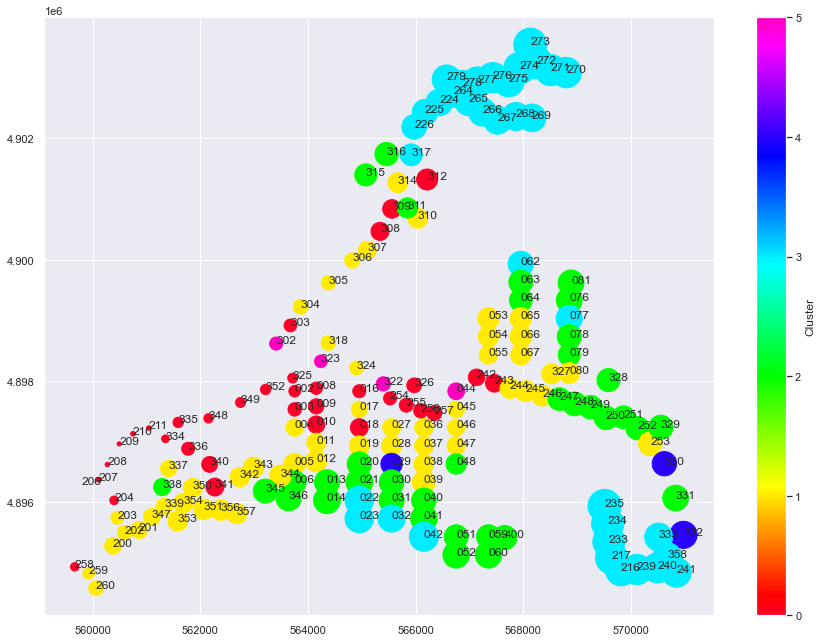

In [91]:
f, ax = plt.subplots(figsize=(15, 11))
plt.scatter(x=latlong_df['X'], 
            y=latlong_df['Y'], 
            c=cutree1, 
            cmap='gist_rainbow', 
            s=(latlong_df['Elv (m)']-latlong_df['Elv (m)'].min()))
plt.colorbar(label='Cluster')

for i, txt in enumerate(latlong_df['Plot']):
    plt.annotate(txt, (latlong_df['X'][i], latlong_df['Y'][i]))

In [92]:
latlong_df["Plot"][cutree1 == 3]

18     022
19     023
25     032
32     042
45     062
52     077
68     216
69     217
70     224
71     225
72     226
73     233
74     234
75     235
76     239
77     240
78     241
98     264
99     265
100    266
101    267
102    268
103    269
104    270
105    271
106    272
107    273
108    274
109    275
110    276
111    277
112    278
113    279
128    317
141    333
165    358
Name: Plot, dtype: object

In [93]:
def is_pos_def(A):
    if np.allclose(A, A.T):
        try:
            np.linalg.cholesky(A)
            return True
        except np.linalg.LinAlgError:
            return False
    else:
        return False

In [94]:
prec = ret.precision_
basis_matrices = []
for i in range(max(set(cutree1))+1): # iterate over clusters
    idxs = np.where(cutree1 == i)[0] # indexes for given cluster
    A = np.zeros(prec.shape) # blank A matrix
    for idx in idxs: # loop over indexes
        for idx2 in idxs: # loop over indexes
            A[idx][idx2] = prec[idx][idx2] # set i,j entry to be the entry from precision matrix for given cluster
            #print(idx, idx2)
    basis_matrices.append(A)
basis_matrices = np.array(basis_matrices)

In [95]:
np.where(cutree1==3)

(array([ 18,  19,  25,  32,  45,  52,  68,  69,  70,  71,  72,  73,  74,
         75,  76,  77,  78,  98,  99, 100, 101, 102, 103, 104, 105, 106,
        107, 108, 109, 110, 111, 112, 113, 128, 141, 165]),)

In [96]:
(basis_matrices.sum(axis=0) == prec).sum()

17883

In [97]:
is_pos_def(basis_matrices.sum(axis=0))

True

In [98]:
basis_matrices.sum(axis=0).shape

(167, 167)

In [99]:
basis_matrices.shape

(6, 167, 167)

In [100]:
cluster_distance_threshold = pairwise_distances.max()/2
idx_to_cluster_array = sch.fcluster(Z, cluster_distance_threshold, 
                                        criterion='distance')
idx = np.argsort(idx_to_cluster_array)
idx

array([140, 138,  22,   0, 134, 133,  66, 124, 121, 120, 115, 142,  95,
        93,  92,  91,  80,  79,  61,  62,  63,  64,  65,  94, 143,  67,
        12,   1, 148, 149, 157, 144,   5,   6, 160,  14,   7, 156, 114,
        33, 130, 131,  90, 158, 161, 159, 162, 163, 164,  82,  81, 145,
        97, 117, 118, 119, 122, 155, 125, 129, 132, 152, 151, 150, 135,
       147,  96, 116,  83,  28,  48,  26,  42,  15,  41,  49,  50,  40,
        13,  55,  20,  27,  36,  35,  21,  57,  58,   2,  59,  60,   3,
         9,  34,  29,   8,  24,  47,  46,  44,  43, 136,  30,  31, 123,
        39,  38, 127,  37, 137, 126, 166,  56,   4,  10,  11,  84,  85,
        86,  87,  88,  89,  23,  54,  17,  51,  53,  16, 154, 139, 153,
       146,  98, 106,  75,  74, 102, 165,  18, 141,  25,  19,  69, 128,
        70,  71,  72,  73,  76,  77,  78,  52,  99, 100,  32, 101, 104,
       105, 107, 108, 109, 110, 111, 112, 113,  68, 103,  45])

<AxesSubplot:>

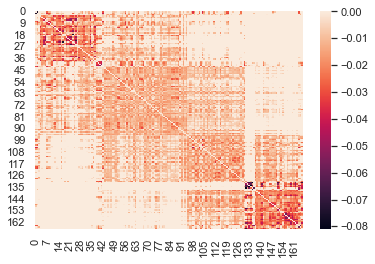

In [101]:
# copy the one without the distance matrix modification (of 999)
precision_copy = ret.precision_.copy()
np.fill_diagonal(precision_copy, 0.)
sns.heatmap(precision_copy[idx, :][:, idx])

In [77]:
precision.max(), precision.min()

(999.080931721184, 0.0)

In [195]:
"""
Try with thresholding away some 'close to zero' values
"""

precision_two = ret.precision_.copy()
precision_two[np.abs(precision_two) <= 0.01] = 0.0
precision_two[precision_two==-0.0] = 10.0
precision_two[precision_two==0.0] = 10.0
precision_two -= precision_two.min()
precision_two

array([[ 1.12754791,  0.03110668, 10.05463897, ...,  0.04145236,
        10.05463897, 10.05463897],
       [ 0.03110668,  1.10578096, 10.05463897, ...,  0.04132858,
        10.05463897, 10.05463897],
       [10.05463897, 10.05463897,  1.14552515, ..., 10.05463897,
        10.05463897, 10.05463897],
       ...,
       [ 0.04145236,  0.04132858, 10.05463897, ...,  1.13430632,
        10.05463897, 10.05463897],
       [10.05463897, 10.05463897, 10.05463897, ..., 10.05463897,
         1.05463897, 10.05463897],
       [10.05463897, 10.05463897, 10.05463897, ..., 10.05463897,
        10.05463897,  1.14575194]])

<AxesSubplot:>

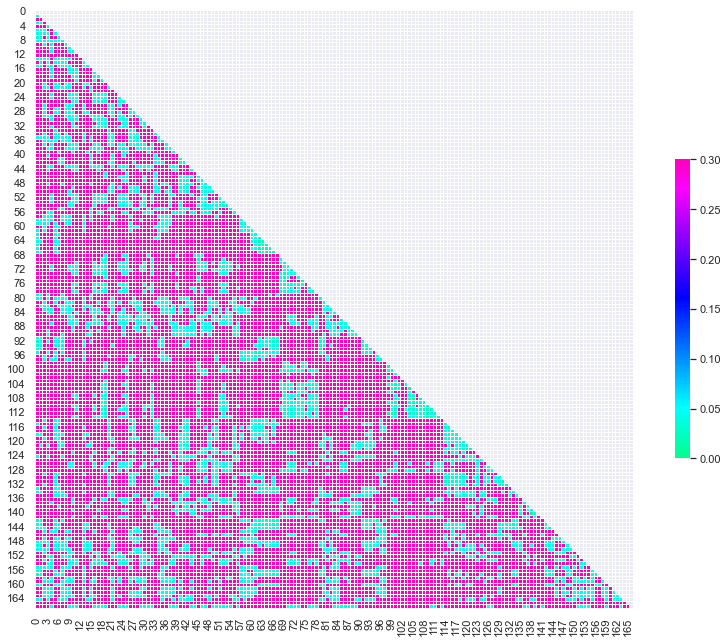

In [196]:
mask = np.triu(np.ones_like(precision_two, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(15, 11))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(precision_two, mask=mask, cmap='gist_rainbow', vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

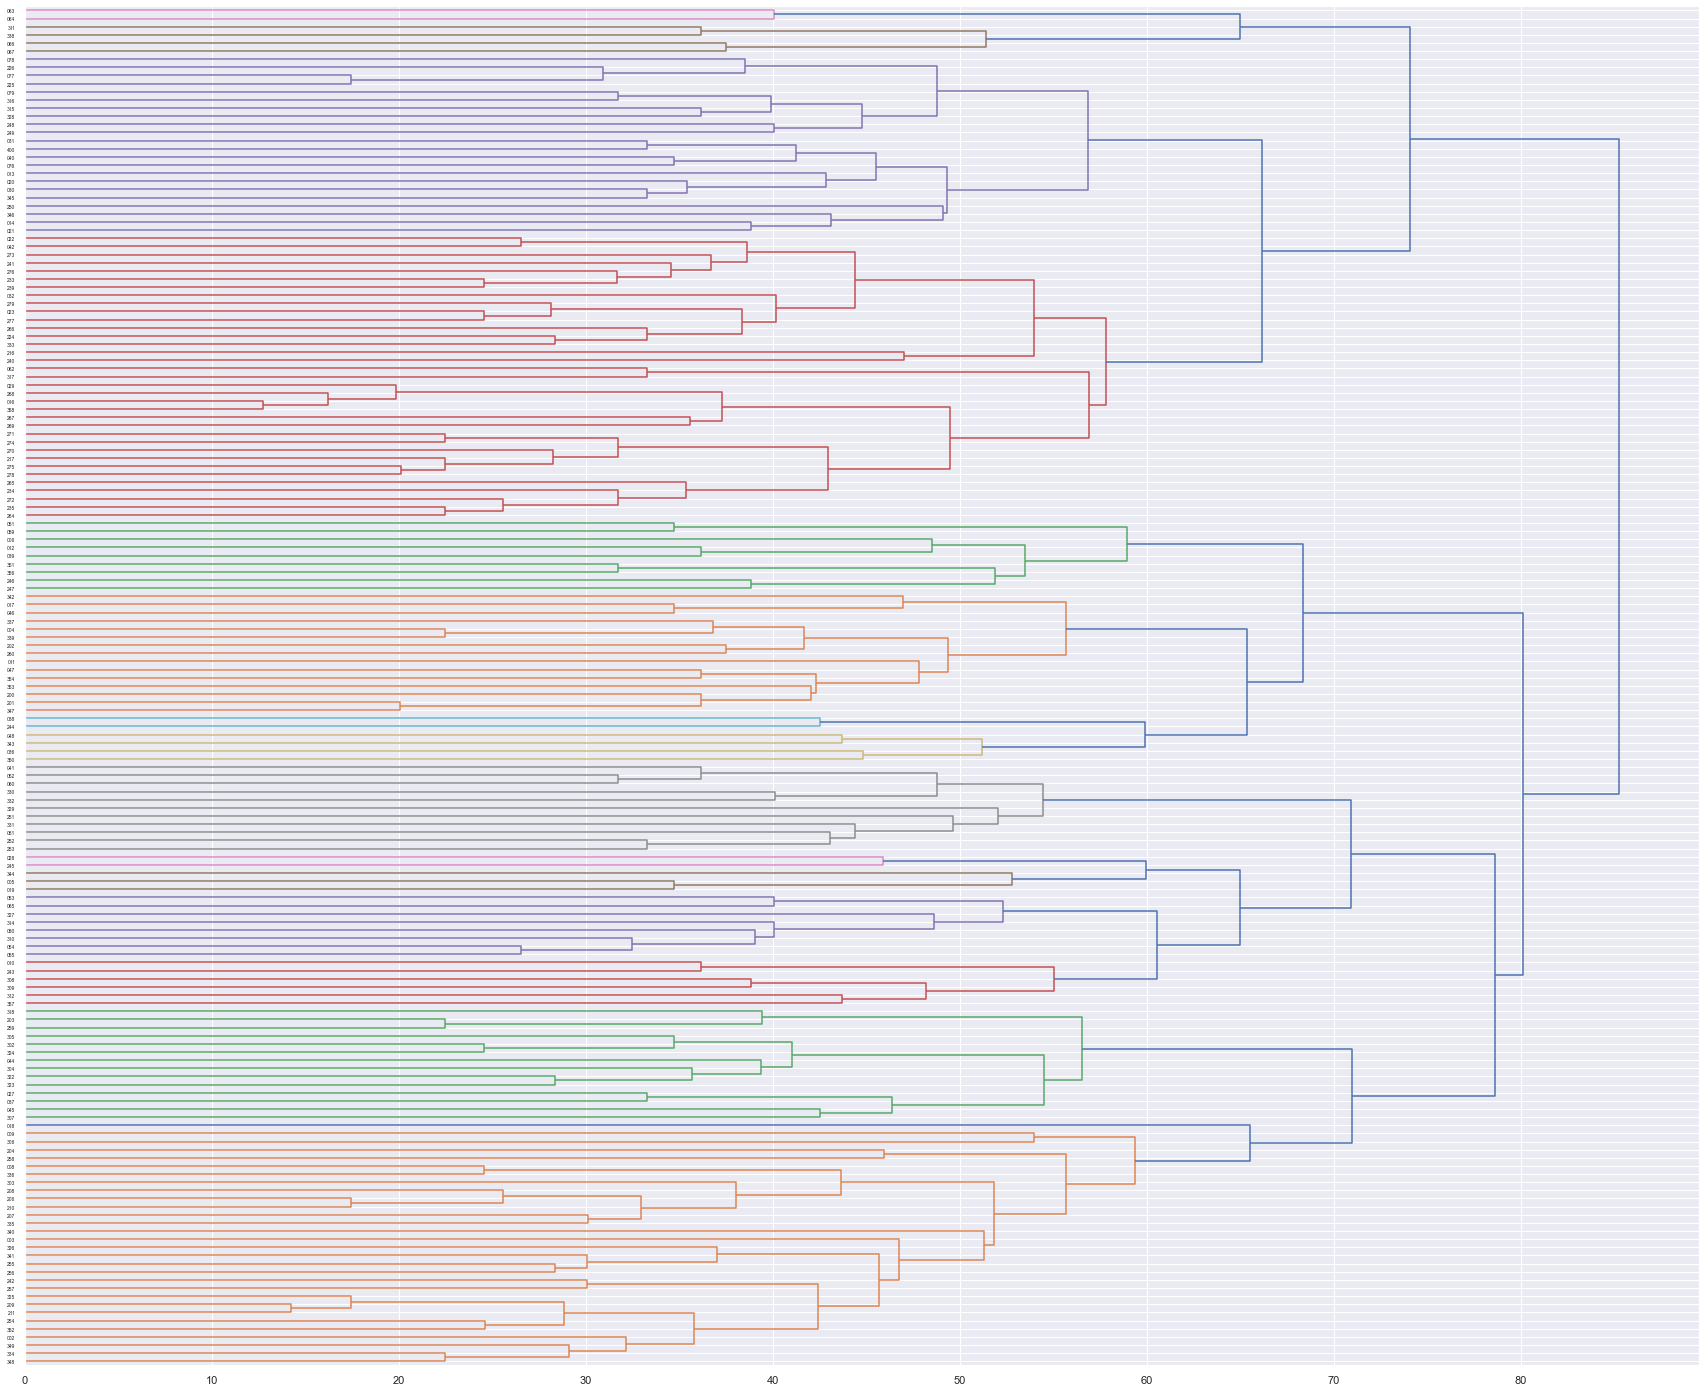

In [197]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import scipy.cluster.hierarchy as sch

pairwise_distances = sch.distance.pdist(precision_two)
Z = linkage(pairwise_distances,
            method='average'  # dissimilarity metric: max distance across all pairs of 
                               # records between two clusters
    )
# calculate full dendrogram and visualize it
plt.figure(figsize=(30, 25))
dendrogram(
            Z,
            orientation='right',
            labels=noon_df.columns,
            distance_sort='descending',
            show_leaf_counts=False
          )
plt.show()

In [198]:
cutree1 = hierarchy.cut_tree(Z, n_clusters=4).squeeze()
cutree1

array([0, 0, 1, 2, 1, 0, 0, 2, 1, 1, 3, 3, 3, 1, 0, 2, 3, 3, 3, 3, 0, 2,
       3, 3, 3, 3, 1, 0, 1, 1, 3, 2, 3, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 1,
       2, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2, 2, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 2, 1, 2, 1, 1, 3, 3, 3,
       2, 2, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 2, 2, 2, 3, 2, 2, 3, 3, 3, 0, 0, 0,
       0, 0, 0, 2, 3, 2, 2, 2, 2, 3, 0, 0, 0, 1, 3, 1, 0, 0, 1, 1, 2, 3,
       3, 1, 0, 0, 1, 1, 0, 1, 1, 1, 2, 3, 3])

/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_6189/3143367495.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Cluster')


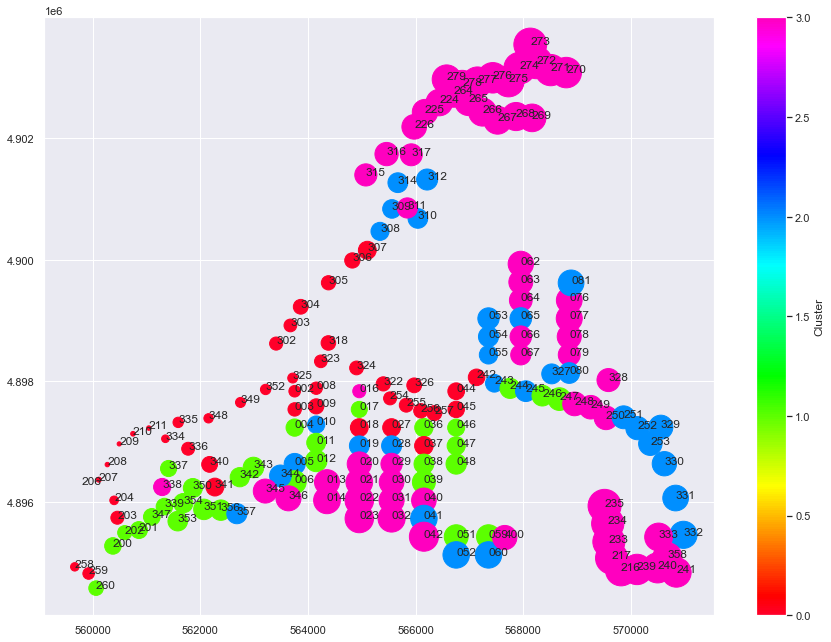

In [199]:
f, ax = plt.subplots(figsize=(15, 11))
plt.scatter(x=latlong_df['X'], 
            y=latlong_df['Y'], 
            c=cutree1, 
            cmap='gist_rainbow', 
            s=(latlong_df['Elv (m)']-latlong_df['Elv (m)'].min()))
plt.colorbar(label='Cluster')

for i, txt in enumerate(latlong_df['Plot']):
    plt.annotate(txt, (latlong_df['X'][i], latlong_df['Y'][i]))

In [1]:
"""
YOU MIGHT HAVE TO FIX THIS LOOP FROM [idx][idx2] to [idx, idx2]
"""

prec = ret.precision_
basis_matrices = []
for i in range(max(set(cutree1))+1): # iterate over clusters
    idxs = np.where(cutree1 == i)[0] # indexes for given cluster
    A = np.zeros(prec.shape) # blank A matrix
    for idx in idxs: # loop over indexes
        for idx2 in idxs: # loop over indexes
            A[idx][idx2] = prec[idx][idx2] # set i,j entry to be the entry from precision matrix for given cluster
            #print(idx, idx2)
    basis_matrices.append(A)
basis_matrices = np.array(basis_matrices)

NameError: name 'ret' is not defined

In [2]:
(basis_matrices.sum(axis=0) == prec).sum()

NameError: name 'basis_matrices' is not defined

In [202]:
basis_matrices.shape

(4, 167, 167)

In [203]:
is_pos_def(basis_matrices.sum(axis=0))

True

In [204]:
basis_matrices.sum(axis=0).shape

(167, 167)

In [105]:
"""
ALTERNATIVE CLUSTERING

Rather than using precision matrix and adding the min, we can just use lasso directly and remove 
things from a total set.
Lasso builds the clusters for us. We can threshold away things as well potentially

This isn't really unique clusters, but it could be used for non-overlapping basis matrix construction, as each 
(i,j) will be unique, even though the same (i) or (j) may be in multiple "clusters"
""";

In [128]:
# increase regularization
from sklearn import covariance, preprocessing

ret = GraphicalLasso(max_iter=1000, alpha=0.9, tol=1e-4).fit(resid_scaled)
ret

GraphicalLasso(alpha=0.9, max_iter=1000)

In [129]:
ret.precision_.min()

-0.054638970873760594

<AxesSubplot:>

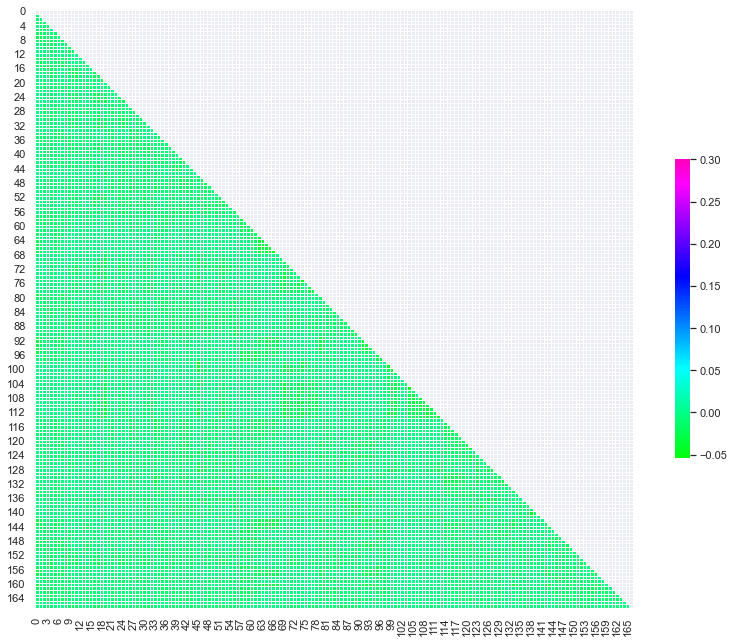

In [130]:
mask = np.triu(np.ones_like(ret.precision_, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(15, 11))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(ret.precision_, mask=mask, cmap='gist_rainbow', vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [151]:
clusters, cvals

([array([  0,   1,   2,   3,   5,   6,   7,   8,  13,  14,  15,  21,  27,
          28,  34,  35,  36,  41,  42,  48,  57,  58,  59,  60,  61,  62,
          63,  64,  65,  66,  67,  79,  80,  82,  83,  84,  90,  91,  92,
          93,  94,  95,  96,  97, 115, 117, 118, 119, 120, 121, 122, 124,
         129, 132, 133, 134, 135, 142, 143, 144, 145, 147, 148, 149, 150,
         152, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164]),
  array([  2,   3,   4,   7,   8,   9,  10,  11,  13,  15,  16,  17,  18,
          19,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  32,
          34,  35,  36,  37,  38,  40,  41,  42,  43,  44,  46,  47,  48,
          50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  70,  71,  72,
          73,  76,  77,  78,  80,  81,  82,  83,  84,  85,  86,  87,  89,
          90,  96,  97, 107, 110, 113, 123, 125, 126, 127, 129, 136, 137,
         139, 145, 147, 150, 151, 152, 153, 154, 155, 158, 159, 161, 162,
         163, 164, 166]),
  array([12]),
  arr

In [149]:
# create set of all RV's
val_set = set(np.arange(ret.precision_.shape[0]))
checked_set = set()
clusters = []
cvals = []
for i in range(ret.precision_.shape[0]):
    if i not in checked_set:
        non_zero = np.where(ret.precision_[i] != 0)[0]
        for item in non_zero:
            if item in val_set:
                val_set.remove(item)
            if item not in checked_set:
                checked_set.add(item)
        clusters.append(non_zero)
        cvals.append(i)

In [67]:
np.linalg.det(np.cov(resid_scaled.T, bias=True))

0.0

In [43]:
np.where(np.triu(np.corrcoef(resid_scaled.T), k=1) >= 0.99)

(array([  0,   0,   0,   0,   0,   2,   2,   2,   2,   2,   2,   2,   2,
          2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,
          2,   2,   2,   2,   2,   3,   3,   3,   3,   3,   4,   4,   5,
          5,   5,   5,   5,   5,   5,   5,   6,   6,   6,   6,   6,   7,
          7,   7,   8,   8,   8,   8,   8,   8,   8,   8,   8,   8,   8,
          8,   8,   8,   8,   8,   8,   8,   8,   9,   9,   9,   9,   9,
          9,   9,   9,   9,   9,   9,   9,   9,   9,   9,   9,   9,  10,
         10,  10,  10,  10,  10,  10,  10,  10,  10,  10,  13,  13,  13,
         13,  13,  13,  13,  13,  13,  13,  13,  13,  13,  13,  13,  13,
         13,  15,  15,  16,  16,  16,  16,  16,  16,  16,  16,  16,  16,
         16,  16,  16,  17,  18,  18,  19,  19,  20,  20,  20,  20,  20,
         20,  20,  20,  20,  20,  20,  20,  20,  21,  21,  21,  21,  21,
         21,  21,  21,  21,  21,  21,  21,  21,  21,  21,  21,  21,  21,
         21,  21,  23,  23,  23,  23,  23,  23,  23

In [55]:
resid_scaled_diff = np.diff(resid_scaled, axis=0)

In [66]:
np.linalg.det(np.cov(resid_scaled_diff.T))

0.0

In [44]:
from statsmodels.graphics.tsaplots import plot_acf

In [72]:
seasonal_diff = df_copy_sorted.diff(24).iloc[24:, :]

In [73]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.structural import UnobservedComponents as UCM
from statsmodels.tsa.seasonal import STL

seasonal_df = pd.DataFrame()
trend_df = pd.DataFrame()
resid_df = pd.DataFrame()
for i in tqdm(range(seasonal_diff.shape[1])):
    model = STL(seasonal_diff.values[:, i], period=365)
    result = model.fit()
    seasonal_df[seasonal_diff.columns[i]] = result.seasonal
    trend_df[seasonal_diff.columns[i]] = result.trend
    resid_df[seasonal_diff.columns[i]] = result.resid
seasonal_df.index = seasonal_diff.index
trend_df.index = seasonal_diff.index
resid_df.index = seasonal_diff.index

  0%|          | 0/167 [00:00<?, ?it/s]

/tmp/ipykernel_3247/3269733601.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  seasonal_df[seasonal_diff.columns[i]] = result.seasonal
/tmp/ipykernel_3247/3269733601.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  trend_df[seasonal_diff.columns[i]] = result.trend
/tmp/ipykernel_3247/3269733601.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To

In [90]:
resid_df_new = resid_df.copy()
resid_df_vals = resid_df_new.values
resid_scaled_new = scaler.fit_transform(np.diff(np.diff(resid_df_vals, axis=0)))

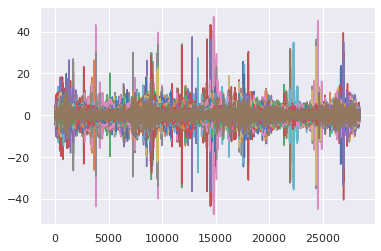

In [91]:
plt.plot(resid_scaled_new);

In [93]:
np.linalg.eig(np.cov(resid_scaled_new.T))[0].min()

0.00012775408796469867

In [94]:
resid_scaled_new.shape

(28462, 166)

In [95]:
np.savetxt('../../data/hj_andrews_resid.csv', resid_scaled_new, delimiter=',')